# Per-run PTQ + results viewer

Loads the float `.keras` model saved by `train.ipynb` and runs post-training
quantization here — so PTQ knobs (`N_REPRESENTATIVE`, `THRESHOLD`,
`DENYLISTED_OPS`, `INT16_ACTIVATIONS`) can be re-explored without retraining.

Outputs are written next to the previous schema-v2 layout:
- `models/<collection>/<run>.tflite` — INT8 model
- `results/<collection>/<run>.json`  — schema-v2 record (metrics + deltas)
- `results/<collection>/<run>.npz`   — y_true / y_score_float / y_score_quant
  plus per-class ROC + threshold-sweep arrays

Below the save step every display from the old viewer (per-species table,
metric-vs-threshold sweep, ROC, float-vs-INT8 comparison, prediction-rates
matrix, deltas) is re-rendered from the live `cmp` so re-quantizing rerenders
everything in place.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os
import pyrootutils

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator='pyproject.toml',
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
# Which trained model to PTQ + evaluate.
COLLECTION = 'task_s3_49_2_r50'
BUILD_MODEL = 'leaf'      # the architecture saved by train.ipynb
RUN_NAME = BUILD_MODEL    # base name for the results json/npz

# Data pipeline (must match train.ipynb so val/test splits line up).
BATCH_SIZE = 16
SEED = 42
NON_TARGET_NAME = 'non_target'

# PTQ knobs — change these and rerun to compare quantizations without retraining.
N_REPRESENTATIVE = 100
THRESHOLD = 0.5                      # per-class decision threshold for the multi-label metrics
# LEAF/PCEN: per-channel learnable tf.pow exponents collapse under full INT8.
# Keep POW/DIV in float (TFLite auto-inserts Q/DQ boundaries around them).
DENYLISTED_OPS = ['POW', 'DIV'] if BUILD_MODEL == 'leaf' else None
INT16_ACTIVATIONS = False            # INT16 activations + INT8 weights; mutually exclusive with denylist

MODEL_PATH = ROOT / 'models' / COLLECTION / f'{BUILD_MODEL}.keras'
TFLITE_PATH = ROOT / 'models' / COLLECTION / f'{BUILD_MODEL}.tflite'
RESULTS_FILE = ROOT / 'results' / COLLECTION / f'{RUN_NAME}.json'
NPZ_FILE = RESULTS_FILE.with_suffix('.npz')
print(f'KERAS : {MODEL_PATH}  exists={MODEL_PATH.exists()}')
print(f'TFLITE: {TFLITE_PATH}')
print(f'JSON  : {RESULTS_FILE}')
print(f'NPZ   : {NPZ_FILE}')

KERAS : /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/leaf.keras  exists=True
TFLITE: /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/leaf.tflite
JSON  : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/leaf.json
NPZ   : /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/leaf.npz


## Available trained models in this collection

In [4]:
models_dir = MODEL_PATH.parent
available = sorted(p.stem for p in models_dir.glob('*.keras'))
for name in available:
    marker = ' ← selected' if name == BUILD_MODEL else ''
    has_tflite = (models_dir / f'{name}.tflite').exists()
    print(f'  {name:<40s}  tflite={"y" if has_tflite else "n"}{marker}')

  cnn1d                                     tflite=n
  leaf                                      tflite=y ← selected
  mel_cnn                                   tflite=y
  sincnet                                   tflite=y
  squeezenet_mel                            tflite=n


## Load dataset catalog + float model

Rebuilds the same per-class cached waveform catalog used at training time
(via the `.cache/<collection>/waveform_<hash>/` cache populated by
`scaling.py`), then constructs the val/test pipelines and loads the float
`.keras` model. Val feeds PTQ calibration; test feeds float-vs-INT8
evaluation.

In [5]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel('ERROR')
logging.getLogger('absl').setLevel('ERROR')
warnings.filterwarnings('ignore', message='.*AudioResample.*')

from building.scaling import (
    build_dataset_from_catalog,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for
from building.models.bake import bake_model
from building.models import model_eval as M
from building import results_io as R

catalog = load_dataset_catalog(COLLECTION)
non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
n_classes = len(final_labels)

input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='val', input_repr=input_repr, augment=False,
)
test_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split='test', input_repr=input_repr, augment=False,
)

# The LEAF custom layers (GaborConv1D / GaussianPool1D / PCEN) don't implement
# get_config, so `tf.keras.models.load_model` can't deserialize a saved .keras
# file. Rebuild the architecture from scratch via model_factory and load only
# the weight values — this is the path the user explicitly asked for.
model = model_factory(BUILD_MODEL)(n_classes)
model.load_weights(MODEL_PATH)
print(f'Rebuilt {BUILD_MODEL} ({n_classes} classes) and loaded weights from {MODEL_PATH}')
print(f'final label order  : {final_labels}')

/home/nathan/Documents/multi-chirp/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 6 objects could not be loaded. Example error message for object <Conv1D name=conv1d, built=True>:

Layer 'conv1d' expected 1 variables, but received 2 variables during loading. Expected: ['kernel']

List of objects that could not be loaded:
[<Conv1D name=conv1d, built=True>, <BatchNormalization name=batch_normalization, built=True>, <Conv1D name=conv1d_1, built=True>, <BatchNormalization name=batch_normalization_1, built=True>, <Dense name=dense, built=True>, <BatchNormalization name=batch_normalization_2, built=True>]

## Post-training quantization

Bakes the float model to an INT8 `.tflite`, calibrated on `val_ds`. Tweak
`N_REPRESENTATIVE`, `DENYLISTED_OPS`, `INT16_ACTIVATIONS` above and rerun
this cell + the cells below to compare quantizations.

In [ ]:
tflite_stats = bake_model(
    model, val_ds, TFLITE_PATH,
    n_representative=N_REPRESENTATIVE,
    denylisted_ops=DENYLISTED_OPS,
    int16_activations=INT16_ACTIVATIONS,
)
print(f'Wrote INT8 .tflite → {TFLITE_PATH}')

## Evaluate float vs INT8 on the test set

Runs both backends through `test_ds`, computes BCE losses on the raw scores,
and binds the live `float_eval`, `quant_eval`, `cmp`, `label_names`,
`non_target_names` used by every display below.

In [ ]:
cmp = M.compare_float_vs_quantized(
    model, TFLITE_PATH, test_ds, final_labels,
    threshold=THRESHOLD, threshold_mode='fixed',
    non_target_names=[NON_TARGET_NAME],
)
float_eval = cmp.float_eval
quant_eval = cmp.quant_eval
label_names = list(quant_eval.label_names)
non_target_names = [NON_TARGET_NAME]

y_true = float_eval.y_true
test_loss_float = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, float_eval.y_score).numpy()
)
test_loss_quant = float(
    tf.keras.losses.BinaryCrossentropy()(y_true, quant_eval.y_score).numpy()
)
qe = quant_eval
print(
    f'INT8 macro-targets — '
    f'precision={qe.macro_precision_targets:.4f}  '
    f'recall={qe.macro_recall_targets:.4f}  '
    f'F1={qe.macro_f1_targets:.4f}  '
    f'F2={qe.macro_f2_targets:.4f}  '
    f'AUC={qe.macro_auc_targets:.4f}'
)
print(f'loss   float={test_loss_float:.4f}   int8={test_loss_quant:.4f}   Δ={test_loss_quant - test_loss_float:+.4f}')
print()
M.print_summary(quant_eval)

## Save record (json + npz)

Schema-v2 record carrying summary metrics + deltas + sampled curves, plus an
`.npz` sidecar with `y_true / y_score_float / y_score_quant` + per-class ROC
and threshold-sweep arrays — enough to recompute any metric later without
rerunning the model.

In [ ]:
record = R.RunRecord.from_comparison(
    cmp,
    non_target_names=[NON_TARGET_NAME],
    tflite_stats=tflite_stats,
    losses=(test_loss_float, test_loss_quant),
    collection=COLLECTION,
    run_name=RUN_NAME,
    build_model=BUILD_MODEL,
    model_path=str(MODEL_PATH),
    tflite_path=str(TFLITE_PATH),
    hyperparams=dict(
        batch_size=BATCH_SIZE, seed=SEED, threshold=THRESHOLD,
        input_repr=input_repr, n_representative=N_REPRESENTATIVE,
        denylisted_ops=DENYLISTED_OPS, int16_activations=INT16_ACTIVATIONS,
    ),
)
record.save(RESULTS_FILE)
meta = record.model_dump(mode='json', by_alias=True)
print(f'Wrote JSON : {RESULTS_FILE}')
print(f'Wrote NPZ  : {NPZ_FILE}')
if meta.get('tflite_stats'):
    s = meta['tflite_stats']
    print(f"\nINT8 footprint: flash={s['model_size_kb']:.1f} KB  "
          f"arena={s.get('arena_size_kb')} KB  MFLOPs={s['flops_mflops']:.3f}")

## Per-species metrics (quantized)

Per-class precision/recall/F1/F2/AUC at the decision threshold saved with the run. `non_target` is included in the table but excluded from the target-only macro printed below.

In [ ]:
tbl = M.per_class_table(quant_eval)
tbl_targets = tbl[~tbl['class'].isin(non_target_names)]
display(tbl_targets.style.format(precision=4).set_caption('Quantized per-species'))
if quant_eval.macro_f1_targets is not None:
    print(
        f'Macro (targets only) — precision={quant_eval.macro_precision_targets:.4f}  '
        f'recall={quant_eval.macro_recall_targets:.4f}  '
        f'F1={quant_eval.macro_f1_targets:.4f}  '
        f'F2={quant_eval.macro_f2_targets:.4f}  '
        f'AUC={quant_eval.macro_auc_targets:.4f}'
    )

,class,support,threshold,precision,recall,f1,f2,auc
0,Emberiza_calandra,1200,0.5000,0.0000,0.0000,0.0000,0.0000,0.4943
1,Hippolais_polyglotta,1165,0.5000,0.1339,0.7708,0.2281,0.3949,0.3956
2,Regulus_ignicapilla,1200,0.5000,0.0000,0.0000,0.0000,0.0000,0.4832


Macro (targets only) — precision=0.0446  recall=0.2569  F1=0.0760  F2=0.1316  AUC=0.4577


## Metric-vs-threshold sweep (paper Fig. 5 style, quantized)

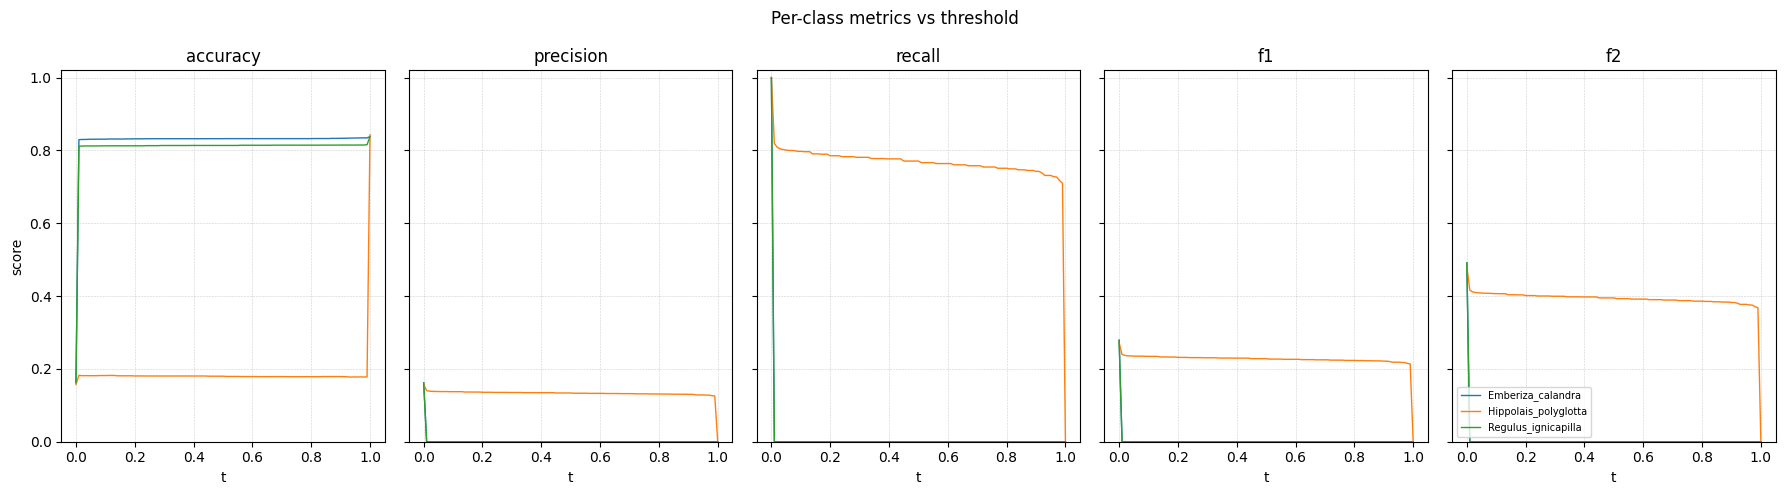

In [ ]:
fig = M.plot_metric_sweep_panel(quant_eval, target_only=True)
plt.show()

## ROC per species (quantized) and AUC

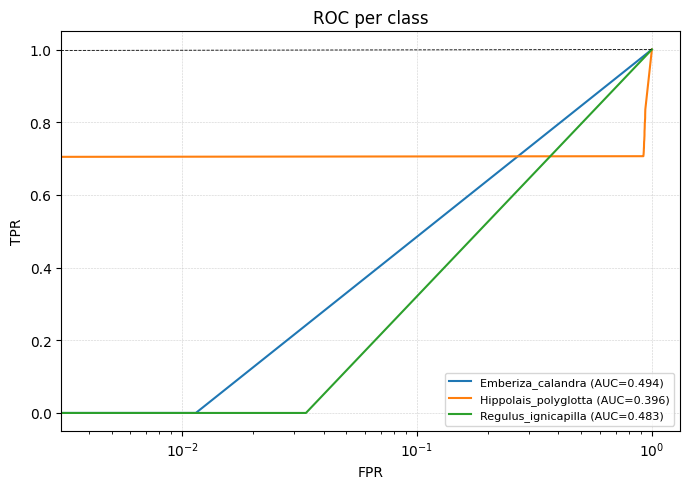

  Emberiza_calandra            AUC=0.4943
  Hippolais_polyglotta         AUC=0.3956
  Regulus_ignicapilla          AUC=0.4832


In [ ]:
fig = M.plot_roc(quant_eval, target_only=True)
plt.show()
for name, mclass in quant_eval.per_class.items():
    if name in non_target_names:
        continue
    print(f'  {name:<28s} AUC={mclass.auc:.4f}' if mclass.auc is not None else f'  {name:<28s} n/a')

## Float vs INT8 comparison

,class,support,f1_float,f1_int8,df1,f2_float,f2_int8,df2,prec_float,prec_int8,rec_float,rec_int8
0,Emberiza_calandra,1200,0.928200,0.000000,-0.928200,0.952800,0.000000,-0.952800,0.889900,0.000000,0.970000,0.000000
1,Hippolais_polyglotta,1165,0.939200,0.228100,-0.711100,0.956400,0.394900,-0.561500,0.911900,0.133900,0.968200,0.770800
2,Regulus_ignicapilla,1200,0.922600,0.000000,-0.922600,0.940800,0.000000,-0.940800,0.893800,0.000000,0.953300,0.000000
3,non_target,3847,0.928700,0.110700,-0.818000,0.897000,0.075800,-0.821200,0.986800,0.475300,0.877000,0.062600
4,MACRO,7412,0.929700,0.084700,-0.845000,0.936800,0.117700,-0.819100,0.920600,0.152300,0.942200,0.208400


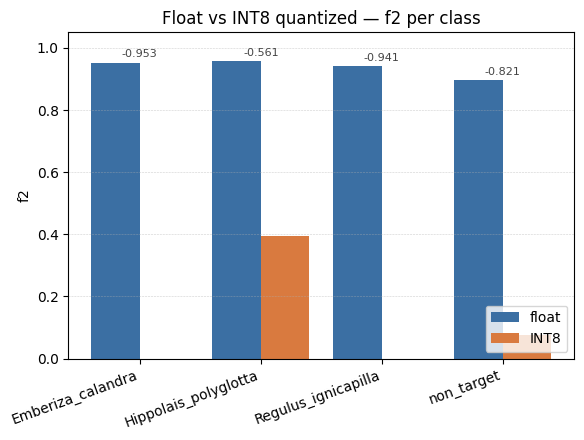

metric                    float       INT8      delta
----------------------------------------------------
top-1 accuracy           0.9304     0.1538    -0.7766
subset accuracy          0.9123     0.1519    -0.7604
macro precision          0.9206     0.1523    -0.7683
macro recall             0.9422     0.2084    -0.7338
macro F1                 0.9297     0.0847    -0.8450
macro F2                 0.9368     0.1177    -0.8191
macro AUC                0.9943     0.4655    -0.5287
avg inference ms         1.5593     4.4915    +2.9322
----------------------------------------------------
flash (weights) KB                    13.2
MFLOPs (est.)                        0.760


In [ ]:
display(M.comparison_table(cmp).style.set_caption('Float vs INT8 per-class'))
fig = M.plot_quantization_drop(cmp, metric='f2')
plt.show()
M.print_comparison(cmp)

## Prediction rates by true class (quantized)

Row-stochastic matrix on the quantized predictions. Diagonal = recall; off-diagonal rows can sum past 1 because predictions are independent (multi-label sigmoid).

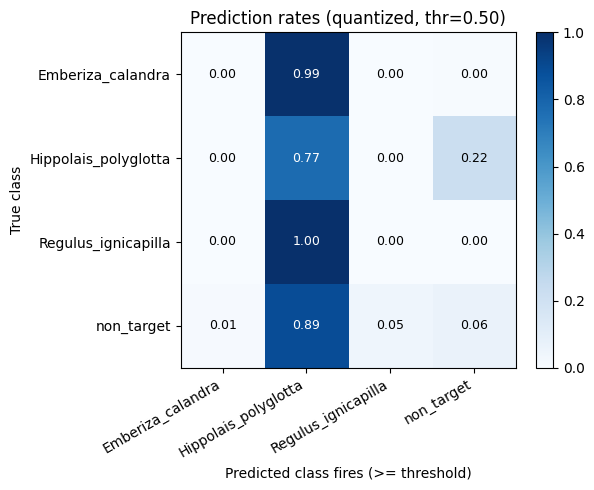

In [ ]:
from building.geographic_task.results_grouped import gather_results  # noqa: F401  (handy import for cross-run work)

THRESHOLD = quant_eval.per_class[label_names[0]].threshold
y_true = quant_eval.y_true
y_score = quant_eval.y_score
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_score >= THRESHOLD).astype(np.int32)

rates = np.zeros((len(label_names), len(label_names)), dtype=np.float64)
for i in range(len(label_names)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha='right')
ax.set_yticks(range(len(label_names)))
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted class fires (>= threshold)')
ax.set_ylabel('True class')
ax.set_title(f'Prediction rates (quantized, thr={THRESHOLD:.2f})')
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(j, i, f'{rates[i, j]:.2f}',
                ha='center', va='center',
                color='white' if rates[i, j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Float vs INT8 — full delta table

Same numbers `train.ipynb` printed at training time, but recomputed from the saved predictions so you can rerun the whole notebook without touching the model.

In [ ]:
deltas = meta.get('deltas', {})
print('macro_targets deltas (INT8 - float):')
for k, v in (deltas.get('macro_targets') or {}).items():
    print(f'  {k:<12s} {v:+.4f}' if v is not None else f'  {k:<12s} n/a')
print('\nper-class F2 delta:')
for name, d in (deltas.get('per_class') or {}).items():
    if name in non_target_names:
        continue
    if d.get('f2') is not None:
        print(f'  {name:<28s} {d["f2"]:+.4f}')

macro_targets deltas (INT8 - float):
  precision    -0.8539
  recall       -0.7069
  f1           -0.8540
  f2           -0.8184
  auc          -0.5388

per-class F2 delta:
  Emberiza_calandra            -0.9528
  Hippolais_polyglotta         -0.5615
  Regulus_ignicapilla          -0.9408


## Cache cleanup (optional)

Wipes the waveform cache built when val/test were materialised — reclaims a
few GB and forces the next run to rebuild from disk so any dataset edits are
picked up automatically. Skip while iterating on PTQ knobs (you'd just rebuild
the cache on the next run).

In [ ]:
from building.scaling import cleanup_waveform_cache

cleanup_waveform_cache(COLLECTION)